In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('world_bank_data_2025.csv',parse_dates=['year'],index_col='year')

In [3]:
df.head()

,country_name,country_id,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
year,,,,,,,,,,,,,,,
2010-01-01,Aruba,aw,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
2011-01-01,Aruba,aw,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2012-01-01,Aruba,aw,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
2013-01-01,Aruba,aw,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
2014-01-01,Aruba,aw,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3472 entries, 2010-01-01 to 2025-01-01
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   Inflation (CPI %)                2694 non-null   float64
 3   GDP (Current USD)                2933 non-null   float64
 4   GDP per Capita (Current USD)     2938 non-null   float64
 5   Unemployment Rate (%)            2795 non-null   float64
 6   Interest Rate (Real, %)          1735 non-null   float64
 7   Inflation (GDP Deflator, %)      2904 non-null   float64
 8   GDP Growth (% Annual)            2912 non-null   float64
 9   Current Account Balance (% GDP)  2563 non-null   float64
 10  Government Expense (% of GDP)    1820 non-null   float64
 11  Government Revenue (% of GDP)    1829 non-null   float64
 12  Ta

In [5]:
df.isnull().sum()

country_name                          0
country_id                            0
Inflation (CPI %)                   778
GDP (Current USD)                   539
GDP per Capita (Current USD)        534
Unemployment Rate (%)               677
Interest Rate (Real, %)            1737
Inflation (GDP Deflator, %)         568
GDP Growth (% Annual)               560
Current Account Balance (% GDP)     909
Government Expense (% of GDP)      1652
Government Revenue (% of GDP)      1643
Tax Revenue (% of GDP)             1639
Gross National Income (USD)         676
Public Debt (% of GDP)             2620
dtype: int64

In [6]:
df.describe()

,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
count,2694.000000,2.933000e+03,2938.000000,2795.000000,1735.000000,2904.000000,2912.000000,2563.000000,1820.000000,1829.000000,1833.000000,2.796000e+03,852.000000
mean,6.233154,3.964323e+11,18483.495612,7.841141,5.405051,6.634865,2.853544,-2.363241,27.325359,26.677467,16.969924,4.142237e+11,61.863736
std,19.726903,1.749315e+12,27301.814024,5.964358,9.740924,25.820196,6.053786,13.740986,12.642464,18.116253,8.218539,1.799783e+12,40.409792
min,-6.687321,3.210541e+07,193.007146,0.100000,-81.132121,-28.760135,-54.336155,-60.877754,0.000136,0.000081,0.000063,5.107533e+07,1.845685
25%,1.402112,6.264757e+09,2280.748732,3.611000,1.734057,1.218347,0.997032,-7.496525,17.511484,17.639153,12.285344,7.475538e+09,33.894232
50%,3.213523,2.587360e+10,6827.668145,5.771000,5.079009,3.223184,3.100442,-2.656009,26.000850,24.821425,16.321438,2.986520e+10,51.651469
75%,6.186626,1.874939e+11,23727.024581,10.731500,8.869434,6.905463,5.355110,1.854710,34.884582,32.700782,21.448658,1.972529e+11,81.930649
max,557.201817,2.772071e+13,256580.515123,35.359000,61.882604,921.535652,86.826748,235.750605,103.725787,344.999451,147.640196,2.757614e+13,249.366027


In [7]:
## Rolling Statistics

window_size=5

for col in df.columns:
    if df[col].dtype!=object:
        df[f'{col}_rolling_mean']=df[col].rolling(window=window_size).mean()
        df[f'{col}_rolling_std']=df[col].rolling(window=window_size).std()
        

In [8]:
df.head()

,country_name,country_id,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),...,Government Expense (% of GDP)_rolling_mean,Government Expense (% of GDP)_rolling_std,Government Revenue (% of GDP)_rolling_mean,Government Revenue (% of GDP)_rolling_std,Tax Revenue (% of GDP)_rolling_mean,Tax Revenue (% of GDP)_rolling_std,Gross National Income (USD)_rolling_mean,Gross National Income (USD)_rolling_std,Public Debt (% of GDP)_rolling_mean,Public Debt (% of GDP)_rolling_std
year,,,,,,,,,,,,,,,,,,,,,
2010-01-01,Aruba,aw,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01,Aruba,aw,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01,Aruba,aw,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01,Aruba,aw,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,Aruba,aw,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,...,NaN,NaN,NaN,NaN,NaN,NaN,2.491193e+09,1.462475e+08,NaN,NaN


In [9]:
df.describe()

,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),...,Government Expense (% of GDP)_rolling_mean,Government Expense (% of GDP)_rolling_std,Government Revenue (% of GDP)_rolling_mean,Government Revenue (% of GDP)_rolling_std,Tax Revenue (% of GDP)_rolling_mean,Tax Revenue (% of GDP)_rolling_std,Gross National Income (USD)_rolling_mean,Gross National Income (USD)_rolling_std,Public Debt (% of GDP)_rolling_mean,Public Debt (% of GDP)_rolling_std
count,2694.000000,2.933000e+03,2938.000000,2795.000000,1735.000000,2904.000000,2912.000000,2563.000000,1820.000000,1829.000000,...,1195.000000,1195.000000,1208.000000,1208.000000,1208.000000,1208.000000,1.978000e+03,1.978000e+03,508.000000,508.000000
mean,6.233154,3.964323e+11,18483.495612,7.841141,5.405051,6.634865,2.853544,-2.363241,27.325359,26.677467,...,27.513406,1.938331,26.966390,1.898809,17.174344,1.152249,4.128110e+11,3.634150e+10,64.123407,6.629915
std,19.726903,1.749315e+12,27301.814024,5.964358,9.740924,25.820196,6.053786,13.740986,12.642464,18.116253,...,12.010327,1.667885,15.867193,6.052444,7.366835,2.621647,1.767388e+12,1.616020e+11,41.661809,5.515162
min,-6.687321,3.210541e+07,193.007146,0.100000,-81.132121,-28.760135,-54.336155,-60.877754,0.000136,0.000081,...,3.999345,0.074605,3.175455,0.031934,0.113692,0.069811,5.415953e+07,3.902786e+06,7.365900,0.310047
25%,1.402112,6.264757e+09,2280.748732,3.611000,1.734057,1.218347,0.997032,-7.496525,17.511484,17.639153,...,17.780876,0.833502,18.115332,0.609865,12.727404,0.451354,7.615799e+09,6.279853e+08,35.373029,2.615342
50%,3.213523,2.587360e+10,6827.668145,5.771000,5.079009,3.223184,3.100442,-2.656009,26.000850,24.821425,...,26.424455,1.572448,25.523973,1.005760,16.558166,0.717963,3.148772e+10,2.922677e+09,53.429122,5.132168
75%,6.186626,1.874939e+11,23727.024581,10.731500,8.869434,6.905463,5.355110,1.854710,34.884582,32.700782,...,35.019292,2.504415,33.097237,1.718128,21.720857,1.222187,1.998887e+11,1.862599e+10,87.643261,8.322040
max,557.201817,2.772071e+13,256580.515123,35.359000,61.882604,921.535652,86.826748,235.750605,103.725787,344.999451,...,90.391790,15.585484,272.898575,117.533594,109.990587,51.969748,2.417260e+13,2.697499e+12,220.667678,32.638046


In [10]:
df.shape

(3472, 41)

In [11]:
## Time Based Features

# # Extract day of the week
# df['day_of_week']=df['year'].dt.dayofweek
# # extract if its weekend
# df['is_weekend']=df['day_of_week'].isin([5,6]).astype(int)
# # extract month, though it will only show january due to only given year in the given data
# df['month']=df['year'].dt.month

# it will only work if the date column is not in index, but I have already took year column in index

In [12]:
# lag features

for col in df.columns:
    if df[col].dtype!=object:
        df[f'{col}_lag_1']=df[col].shift(1)
        df[f'{col}_lag_2']=df[col].shift(2)
        df[f'{col}_lag_3']=df[col].shift(3)

C:\Users\91637\AppData\Local\Temp\ipykernel_22444\3436484241.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_1']=df[col].shift(1)
C:\Users\91637\AppData\Local\Temp\ipykernel_22444\3436484241.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_lag_2']=df[col].shift(2)
C:\Users\91637\AppData\Local\Temp\ipykernel_22444\3436484241.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

In [13]:
df.head()

,country_name,country_id,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),...,Gross National Income (USD)_rolling_mean_lag_3,Gross National Income (USD)_rolling_std_lag_1,Gross National Income (USD)_rolling_std_lag_2,Gross National Income (USD)_rolling_std_lag_3,Public Debt (% of GDP)_rolling_mean_lag_1,Public Debt (% of GDP)_rolling_mean_lag_2,Public Debt (% of GDP)_rolling_mean_lag_3,Public Debt (% of GDP)_rolling_std_lag_1,Public Debt (% of GDP)_rolling_std_lag_2,Public Debt (% of GDP)_rolling_std_lag_3
year,,,,,,,,,,,,,,,,,,,,,
2010-01-01,Aruba,aw,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01,Aruba,aw,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01,Aruba,aw,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01,Aruba,aw,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,Aruba,aw,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df['country_name'].unique()

array(['Aruba', 'Afghanistan', 'Angola', 'Albania', 'Andorra',
       'United Arab Emirates', 'Argentina', 'Armenia', 'American Samoa',
       'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan',
       'Burundi', 'Belgium', 'Benin', 'Burkina Faso', 'Bangladesh',
       'Bulgaria', 'Bahrain', 'Bahamas, The', 'Bosnia and Herzegovina',
       'Belarus', 'Belize', 'Bermuda', 'Bolivia', 'Brazil', 'Barbados',
       'Brunei Darussalam', 'Bhutan', 'Botswana',
       'Central African Republic', 'Canada', 'Switzerland',
       'Channel Islands', 'Chile', 'China', "Cote d'Ivoire", 'Cameroon',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Colombia', 'Comoros',
       'Cabo Verde', 'Costa Rica', 'Cuba', 'Curacao', 'Cayman Islands',
       'Cyprus', 'Czechia', 'Germany', 'Djibouti', 'Dominica', 'Denmark',
       'Dominican Republic', 'Algeria', 'Ecuador', 'Egypt, Arab Rep.',
       'Eritrea', 'Spain', 'Estonia', 'Ethiopia', 'Finland', 'Fiji',
       'France', 'Faroe Islands', 'Micronesia, Fed

In [15]:
# frequency based features

from scipy.fftpack import fft   # Fast fourier transform: FFT transforms the time series data into the frequency domain, 
                                # resulting in complex values representing amplitudes of sinusoidal components at various frequencies.
from statsmodels.tsa.seasonal import seasonal_decompose



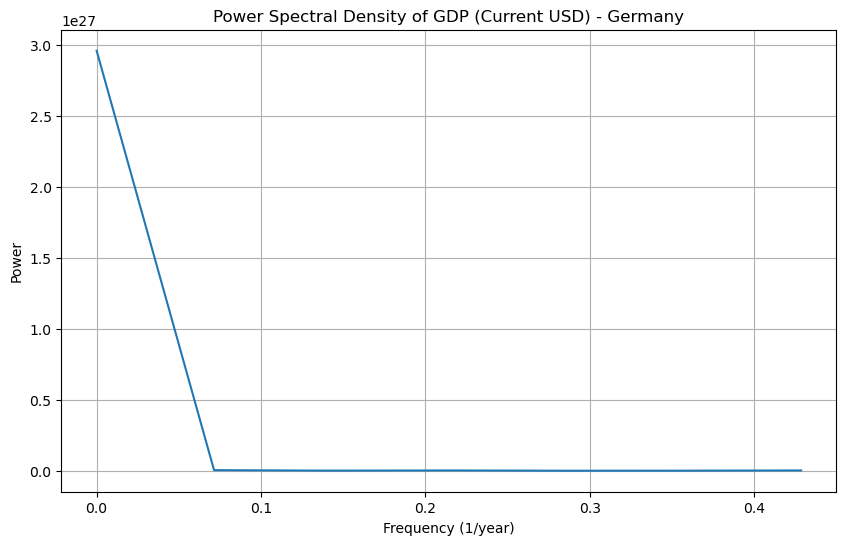

Top Peak Frequencies (1/year): [-0.21428571  0.21428571  0.07142857 -0.07142857  0.        ]
Corresponding Periods (years): [ -4.66666667   4.66666667  14.         -14.                  inf]


C:\Users\91637\AppData\Local\Temp\ipykernel_22444\3384734754.py:29: RuntimeWarning: divide by zero encountered in divide
  print("Corresponding Periods (years):", 1/peak_freq)


In [22]:


# Example: Select India's GDP
country = "Germany"
indicator = "GDP (Current USD)"
ts = df[df['country_name'] == country][indicator].dropna()

# Sort by date if not already sorted
ts = ts.sort_index()

# Apply FFT
fft_values = fft(ts.values)
fft_frequencies = np.fft.fftfreq(len(fft_values), d=1)  # d=1 means 1 year interval

# Compute Power Spectral Density
psd = np.abs(fft_values) ** 2

# Plot Power Spectral Density
plt.figure(figsize=(10, 6))
plt.plot(fft_frequencies[:len(fft_frequencies)//2], psd[:len(psd)//2])  # Only positive frequencies
plt.title(f'Power Spectral Density of {indicator} - {country}')
plt.xlabel('Frequency (1/year)')
plt.ylabel('Power')
plt.grid(True)
plt.show()

# Find Top 5 Peak Frequencies
top_n = 5
peak_freq = fft_frequencies[np.argsort(psd)[-top_n:]]
print("Top Peak Frequencies (1/year):", peak_freq)
print("Corresponding Periods (years):", 1/peak_freq)


In [29]:
df.head()

,country_name,country_id,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),...,Gross National Income (USD)_rolling_mean_lag_3,Gross National Income (USD)_rolling_std_lag_1,Gross National Income (USD)_rolling_std_lag_2,Gross National Income (USD)_rolling_std_lag_3,Public Debt (% of GDP)_rolling_mean_lag_1,Public Debt (% of GDP)_rolling_mean_lag_2,Public Debt (% of GDP)_rolling_mean_lag_3,Public Debt (% of GDP)_rolling_std_lag_1,Public Debt (% of GDP)_rolling_std_lag_2,Public Debt (% of GDP)_rolling_std_lag_3
year,,,,,,,,,,,,,,,,,,,,,
2010-01-01,Aruba,aw,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01,Aruba,aw,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-01,Aruba,aw,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-01,Aruba,aw,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01-01,Aruba,aw,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\91637\AppData\Local\Temp\ipykernel_22444\3350206708.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = df[df['country_name'] == 'India']['GDP (Current USD)'].fillna(method='ffill')


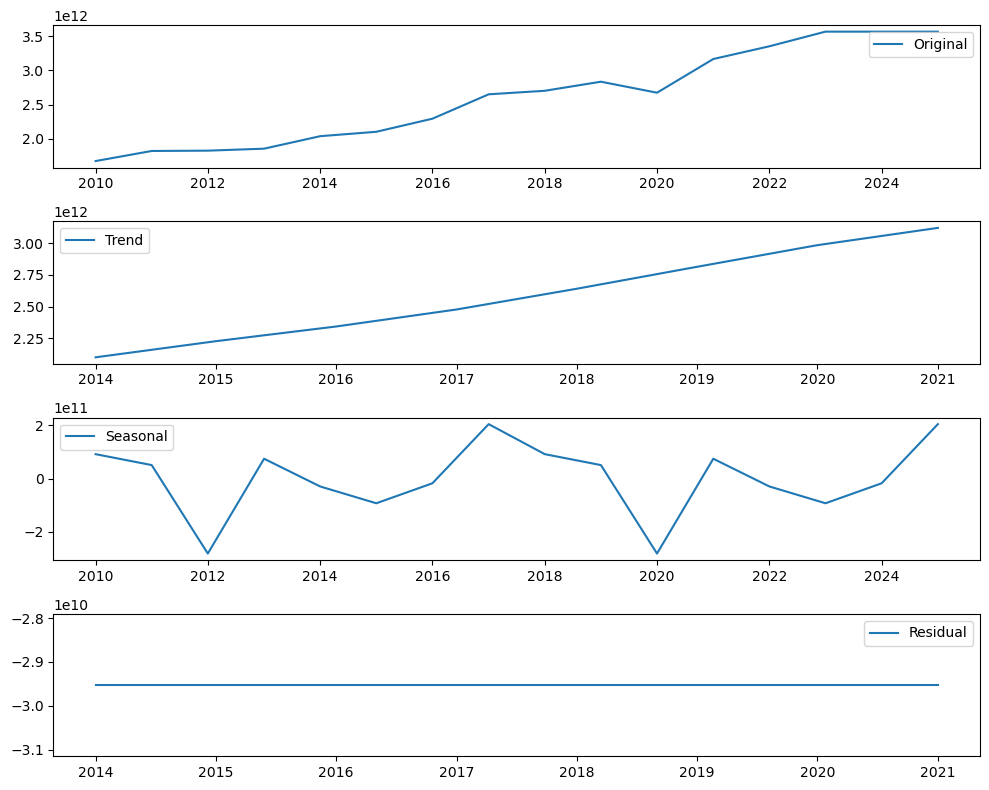

In [34]:
series = df[df['country_name'] == 'India']['GDP (Current USD)'].fillna(method='ffill')
# OR
# series = series.interpolate(method='linear')

decompose = seasonal_decompose(series, period=8, model='additive')
original=decompose.observed 
trend=decompose.trend
seasonal=decompose.seasonal
residual=decompose.resid

plt.figure(figsize=(10,8))

plt.subplot(411)
plt.plot(original.index,original,label='Original')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(trend.index,trend,label='Trend')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(seasonal.index,seasonal,label='Seasonal')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(residual.index,residual,label='Residual')
plt.legend(loc='best')
# decompose.plot()

plt.tight_layout()
plt.show()